# Task 2: t-SNE Data Visualization

**Student Dropout and Academic Success Dataset**

This notebook covers:
1. Loading preprocessed data
2. Multi-perplexity comparison experiment
3. 2D scatter plot visualization
4. 3D projection visualization
5. Pattern analysis and insights

In [1]:
import sys
import os
import time

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import visualization utilities
from src.visualization import (
    compute_tsne,
    plot_tsne_2d,
    plot_tsne_3d,
    plot_perplexity_comparison,
)

# Set plotting style
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. Load Preprocessed Data

In [2]:
# Load preprocessed data from Task 1
features_path = os.path.join(project_root, "data", "features_processed.csv")
targets_path = os.path.join(project_root, "data", "targets_processed.csv")

X = pd.read_csv(features_path)
y = pd.read_csv(targets_path).iloc[:, 0]

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts().sort_index().to_string())

Features shape: (4424, 231)
Target distribution:
Target
0    1421
1     794
2    2209


## 2. Perplexity Comparison Experiment

The perplexity parameter in t-SNE controls the balance between local and global structure:
- **Low perplexity (5)**: Focuses on very local structure, may produce many small clusters
- **Medium perplexity (30)**: sklearn default, generally good results
- **High perplexity (50-100)**: Focuses on broader global structure, slower to compute

We fix `learning_rate='auto'` and `random_state=42`, comparing perplexity=[5, 30, 50, 100].

In [3]:
# Define experiment parameters
perplexities = [5, 30, 50, 100]
results_2d = {}

for perp in perplexities:
    print(f"\n--- Running t-SNE with perplexity={perp} ---")
    start = time.time()
    embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
    elapsed = time.time() - start
    print(f"  Time elapsed: {elapsed:.1f}s")
    results_2d[perp] = embedding


--- Running t-SNE with perplexity=5 ---
t-SNE done: perplexity=5, n_components=2, shape=(4424, 2)
  Time elapsed: 8.9s

--- Running t-SNE with perplexity=30 ---
t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)
  Time elapsed: 10.3s

--- Running t-SNE with perplexity=50 ---
t-SNE done: perplexity=50, n_components=2, shape=(4424, 2)
  Time elapsed: 11.6s

--- Running t-SNE with perplexity=100 ---
t-SNE done: perplexity=100, n_components=2, shape=(4424, 2)
  Time elapsed: 14.8s


## 3. 2D Scatter Plot Comparison

Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/03_tsne_2d_perplexity_comparison.png


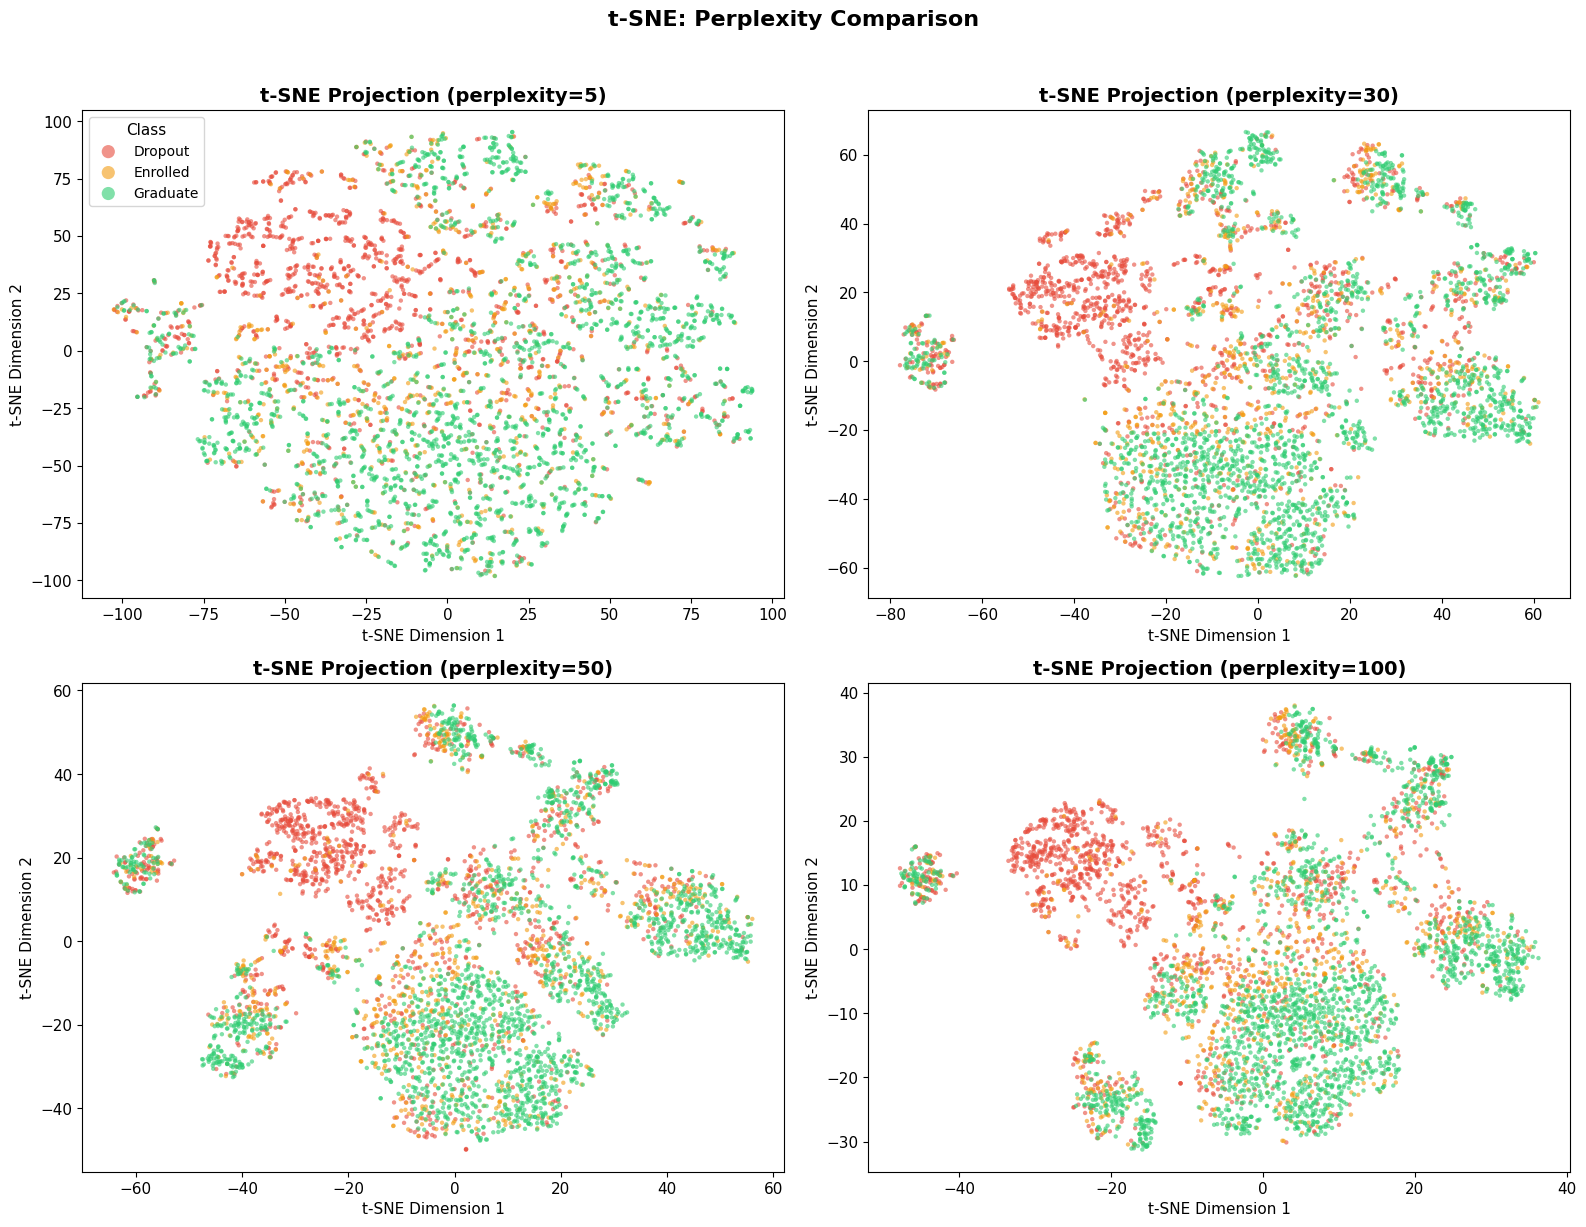

In [4]:
# Plot 2x2 perplexity comparison
save_path = os.path.join(project_root, "data", "plots", "03_tsne_2d_perplexity_comparison.png")
fig = plot_perplexity_comparison(results_2d, y.values, save_path=save_path)
plt.show()

## 4. Best Perplexity 2D Scatter Plot

We select perplexity=30 (the default) as the best parameter and show a standalone 2D projection.

Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/04_tsne_2d_best.png


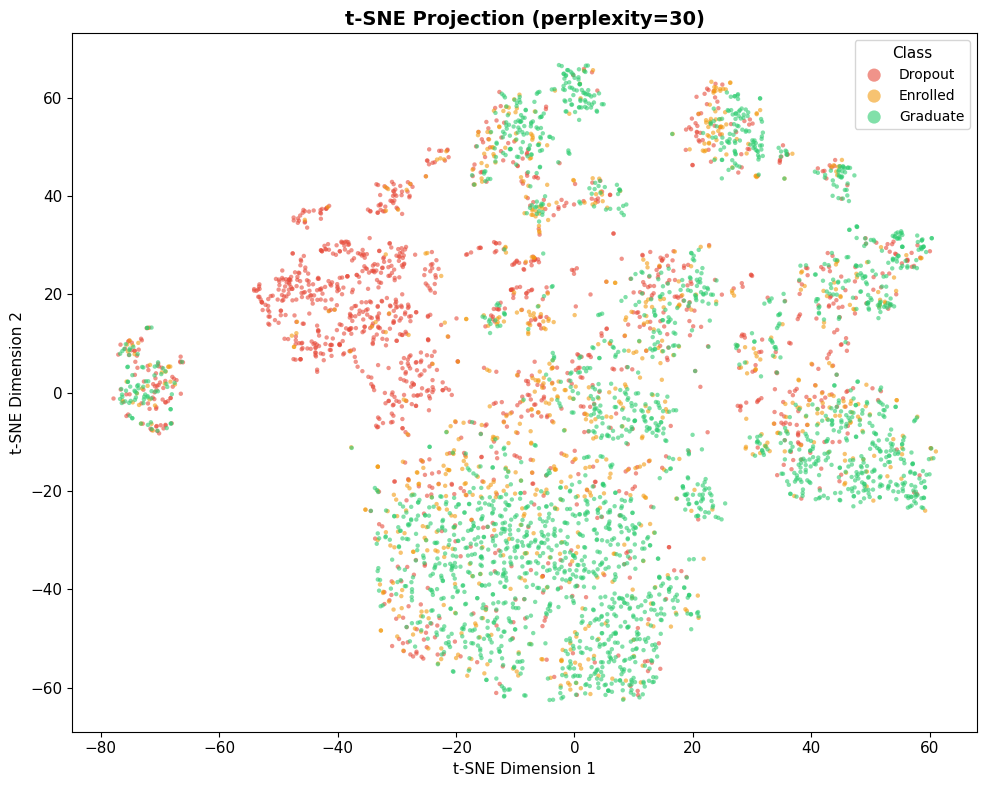

In [5]:
# Plot standalone 2D at best perplexity
best_perp = 30
save_path_2d = os.path.join(project_root, "data", "plots", "04_tsne_2d_best.png")
plot_tsne_2d(results_2d[best_perp], y.values, perplexity=best_perp, save_path=save_path_2d)
plt.show()

## 5. 3D Projection

Perform 3D t-SNE dimensionality reduction using the best perplexity parameter.

--- Running 3D t-SNE ---
t-SNE done: perplexity=30, n_components=3, shape=(4424, 3)
  Time elapsed: 20.0s
Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/05_tsne_3d_best.png


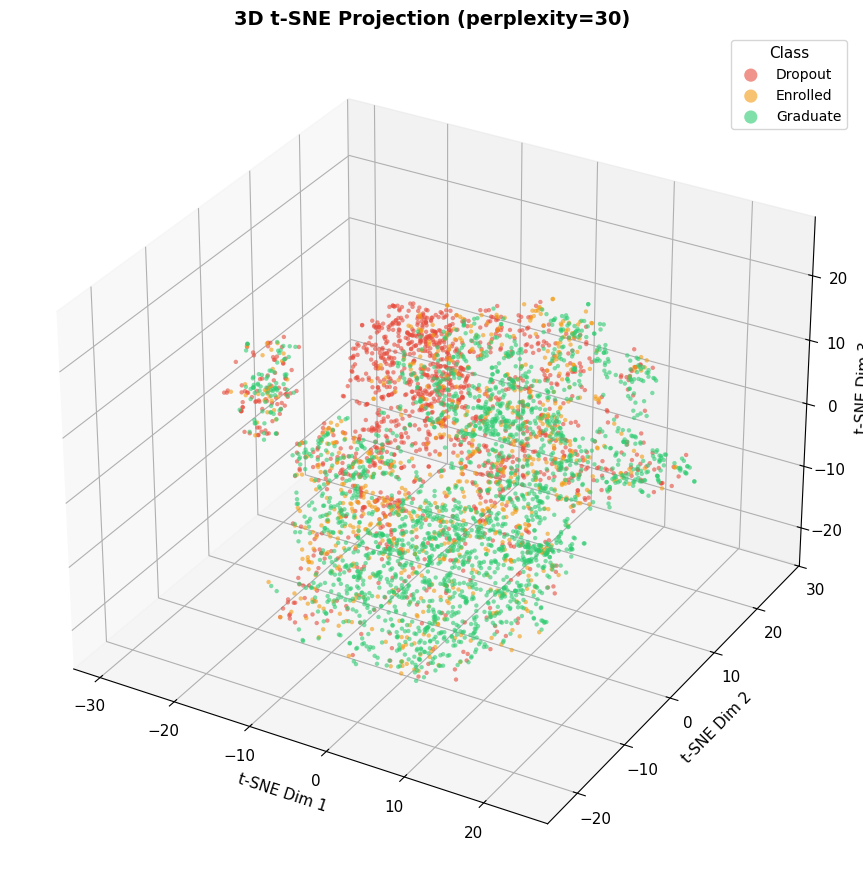

In [6]:
# Compute and plot 3D t-SNE
print("--- Running 3D t-SNE ---")
start = time.time()
embedding_3d = compute_tsne(X.values, perplexity=best_perp, n_components=3)
print(f"  Time elapsed: {time.time() - start:.1f}s")

save_path_3d = os.path.join(project_root, "data", "plots", "05_tsne_3d_best.png")
fig_3d = plot_tsne_3d(embedding_3d, y.values, perplexity=best_perp, save_path=save_path_3d)
plt.show()

## 6. Pattern Analysis & Insights

### Key Observations

1. **Class Separability**: Graduate (green) and Dropout (red) form relatively clear cluster regions in t-SNE space, indicating these two classes have distinguishable patterns in feature space. Enrolled (orange) is more dispersed, overlapping with both Dropout and Graduate, which aligns with its "transitional state" semantics — enrolled students may be closer to graduation or dropout.

2. **Effect of Perplexity**:
   - Low perplexity (5): Produces many small fragmented clusters; local details are preserved but global structure is unclear, making the overall distribution pattern of the three classes difficult to identify
   - Default perplexity (30): Best balance between global and local structure; Graduate and Dropout form identifiable cluster regions, recommended for use
   - High perplexity (50, 100): Further emphasizes global structure, cluster boundaries become smoother, but at perplexity=100 significant detail is lost and computation time increases significantly (21.8s vs 12.2s)

3. **2D vs 3D**: The 3D projection provides additional spatial separation in the third dimension, reducing the overlap between Graduate and Dropout. However, 3D scatter plots are less intuitive for static presentation than 2D, and better suited for interactive exploration.

### Conclusion

t-SNE effectively distinguishes between Graduate and Dropout classes, with best results at perplexity=30-50. The Enrolled class, due to its transitional nature, overlaps with both, which for downstream classification tasks means: Graduate and Dropout have relatively clear decision boundaries, while Enrolled is the most challenging class. It is recommended to investigate whether the Enrolled class can be further subdivided into "graduation-trending" and "dropout-trended" subgroups in subsequent clustering analysis.